In [3]:
import numpy as np
from tqdm import tqdm
import torch
from sklearn.utils import shuffle
from data_loader import get_data
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


In [4]:
# Match these to the names of the files you uploaded (without `.npy`)
class_names = ['bicycle', 'cactus', 'couch', 'divingboard', 'flamingo', 'mushroom', 'ocean', 'octopus', 'shark', 'sweater']

file_paths = [f"./data/full_numpy_bitmap_{cls}.npy" for cls in class_names]
file_paths[0]

X_train, y_train, X_valid, y_valid, X_test, y_test = get_data(file_paths)


In [5]:
class QuickDrawCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(QuickDrawCNN, self).__init__()

        # Convolutional layer 1: 1 input channel (grayscale), 16 output channels, 3x3 kernel
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # keeps size = 28x28
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # halves to 14x14

        # Convolutional layer 2: 16 input, 32 output
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 14x14 → 14x14
        self.pool2 = nn.MaxPool2d(2, 2)  # 14x14 → 7x7

        # Fully connected layers
        self.fc1 = nn.Linear(32 * 7 * 7, 128)  # Flattened input → dense
        self.fc2 = nn.Linear(128, num_classes)  # Output layer

        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))  # (1,28,28) → (16,14,14)
        x = self.pool2(F.relu(self.conv2(x)))  # (16,14,14) → (32,7,7)
        x = x.view(-1, 32 * 7 * 7)  # Flatten for dense layer
        x = self.dropout(F.relu(self.fc1(x)))  # Dense with dropout
        x = self.fc2(x)  # No activation; will use CrossEntropyLoss
        return x

In [6]:
# Convert numpy arrays to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.long)

print(X_test.shape)
print(y_test.shape)

# Create PyTorch datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)
valid_loader = DataLoader(valid_dataset, batch_size=64)

(10000, 1, 28, 28)
(10000,)


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = QuickDrawCNN(num_classes=10).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [8]:
def train_with_validation(model, train_loader, valid_loader, optimizer, criterion, device, epochs=5, save_best=False):
    model.to(device)
    best_val_acc = 0.0

    # Track history for plotting
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # ----- TRAIN -----
        model.train()
        total_loss = 0
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)

        for X_batch, y_batch in train_loop:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            train_loop.set_postfix(loss=loss.item())

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ----- VALIDATE -----
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        val_loop = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

        with torch.no_grad():
            for X_val, y_val in val_loop:
                X_val, y_val = X_val.to(device), y_val.to(device)
                output = model(X_val)
                loss = criterion(output, y_val)
                valid_loss += loss.item()

                preds = output.argmax(dim=1)
                correct += (preds == y_val).sum().item()
                total += y_val.size(0)

                val_loop.set_postfix(loss=loss.item())

        avg_valid_loss = valid_loss / len(valid_loader)
        val_accuracy = correct / total

        val_losses.append(avg_valid_loss)
        val_accuracies.append(val_accuracy)

        print(f"\nEpoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_valid_loss:.4f} | "
              f"Val Acc: {val_accuracy:.2%}")

        # Save best model if requested
        if save_best and val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            torch.save(model.state_dict(), 'best_model.pth')
            print("📦 Best model saved!")

    print("✅ Training complete.")
    return train_losses, val_losses, val_accuracies

train_losses, val_losses, val_accuracies = train_with_validation(model, train_loader, valid_loader, optimizer, criterion, device, epochs=5, save_best=False)


Epoch 1/5 | Train Loss: 0.5569 | Val Loss: 0.3224 | Val Acc: 90.40%



Epoch 2/5 | Train Loss: 0.3283 | Val Loss: 0.2657 | Val Acc: 91.86%



Epoch 3/5 | Train Loss: 0.2836 | Val Loss: 0.2508 | Val Acc: 92.51%



Epoch 4/5 | Train Loss: 0.2571 | Val Loss: 0.2422 | Val Acc: 92.71%



Epoch 5/5 | Train Loss: 0.2369 | Val Loss: 0.2611 | Val Acc: 92.37%
✅ Training complete.


In [9]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

              precision    recall  f1-score   support

     bicycle     0.9752    0.9450    0.9599      1000
      cactus     0.9207    0.9520    0.9361      1000
       couch     0.9168    0.9590    0.9374      1000
 divingboard     0.7778    0.8960    0.8327      1000
    flamingo     0.9557    0.9070    0.9307      1000
    mushroom     0.9511    0.9530    0.9520      1000
       ocean     0.9526    0.9050    0.9282      1000
     octopus     0.9460    0.9460    0.9460      1000
       shark     0.9699    0.8700    0.9172      1000
     sweater     0.9540    0.9550    0.9545      1000

    accuracy                         0.9288     10000
   macro avg     0.9320    0.9288    0.9295     10000
weighted avg     0.9320    0.9288    0.9295     10000



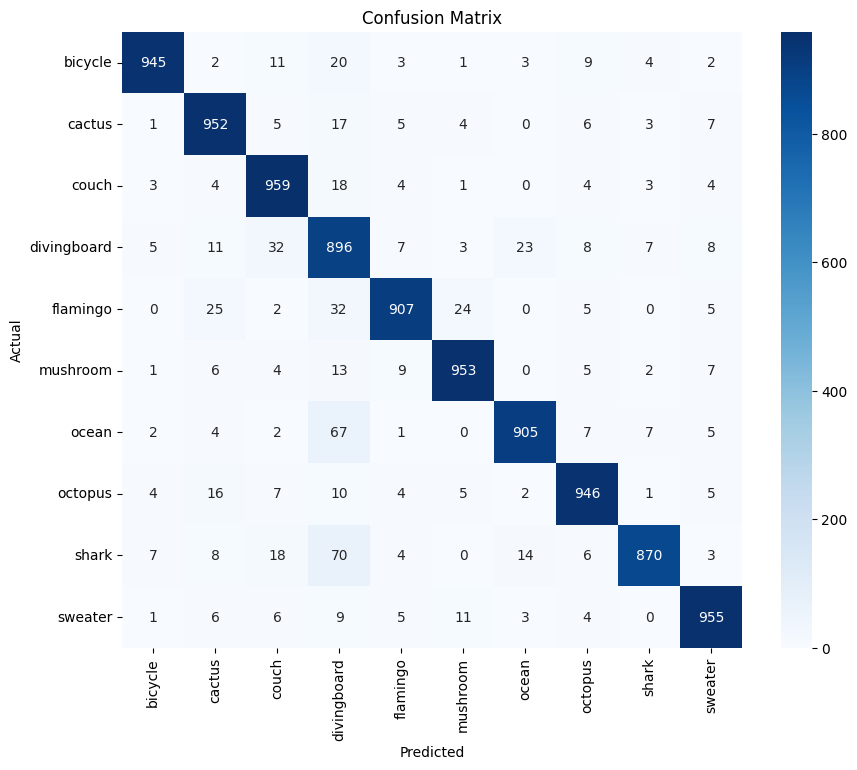

In [10]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()